# Laboratorio 4. Parte 2 - Modelos con datos geoespaciales

**Avance: ejercicios 1, 2 y 3**  
**Integrantes:** Milton Polanco y Osman de León  
**Curso:** CC3084 - Data Science

En este avance se construye el conjunto de datos por píxel, se define la variable respuesta binaria y se seleccionan los predictores que se usarán en los modelos. El resultado de cianobacteria sigue siendo una estimación satelital de clorofila-a; no sustituye una medición de campo ni confirma toxicidad.

## 1. Preparación de los datos para Machine Learning

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from parte_2.src.analisis import (
    EXCLUIDAS_POR_FUGA,
    PREDICTORES_CATEGORICOS,
    PREDICTORES_NUMERICOS,
    construir_resumenes,
    generar_figuras,
)
from parte_2.src.preparacion import (
    ARCHIVO_DATOS,
    ARCHIVO_OBSERVACIONES,
    ARCHIVO_VARIABLES,
    UMBRAL_ALTO,
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda valor: f"{valor:,.3f}")

### Construcción de cada observación

Cada fila representa el centro de un píxel de 20 m clasificado como agua dentro del rectángulo de uno de los lagos. Para conservar la ubicación se guardaron coordenadas geográficas y coordenadas en **WGS 84 / UTM zona 15N (EPSG:32615)**. También se conservaron la fecha, el lago, el satélite, siete bandas, NDVI, NDWI, NDCI y la concentración estimada de clorofila-a.

El archivo completo se genera con `python -m parte_2.src.preparacion`. La descarga queda separada por lago y fecha para poder reanudarla sin repetir las escenas ya procesadas.

In [2]:
datos = pd.read_parquet(ARCHIVO_DATOS)
resumen_observaciones = pd.read_csv(ARCHIVO_OBSERVACIONES, parse_dates=["fecha"])

pd.Series({
    "filas": len(datos),
    "columnas": datos.shape[1],
    "lagos": datos["lago"].nunique(),
    "combinaciones lago-fecha con datos": datos[["lago", "fecha"]].drop_duplicates().shape[0],
    "fechas de la consigna sin escena": int((resumen_observaciones["estado"] == "sin escena").sum()),
}, name="resultado")

filas                                 1781186
columnas                                   25
lagos                                       2
combinaciones lago-fecha con datos         21
fechas de la consigna sin escena            1
Name: resultado, dtype: int64

In [3]:
conteo_lago = datos.groupby("lago").size().rename("observaciones").to_frame()
conteo_fecha = datos.groupby(["lago", "fecha"]).size().rename("observaciones").reset_index()
display(conteo_lago)
display(conteo_fecha)

,observaciones
lago,
Amatitlán,247417
Atitlán,1533769


,lago,fecha,observaciones
0,Amatitlán,2025-01-28,26707
1,Amatitlán,2025-04-15,9970
2,Amatitlán,2025-04-28,22053
3,Amatitlán,2025-11-24,29435
4,Amatitlán,2026-01-08,30771
5,Amatitlán,2026-02-02,2441
6,Amatitlán,2026-02-07,7746
7,Amatitlán,2026-03-29,21532
8,Amatitlán,2026-04-13,33893
9,Amatitlán,2026-04-28,32697


La diferencia en el número de filas entre lagos era esperable: Atitlán tiene una superficie mucho mayor. El 13 de abril de 2025 no apareció una adquisición Sentinel-2C que intersectara Atitlán. No se sustituyó por otra fecha porque la consigna pide usar las fechas oficiales.

### Limpieza aplicada

1. Las reflectancias L2A se dividieron entre 10,000 y se llevaron a una malla común de 20 m en EPSG:32615.
2. Se retiraron las clases SCL 0, 3, 8, 9, 10 y 11: NoData, sombra de nube, nubes, cirrus y nieve/hielo.
3. La superficie de agua se delimitó combinando NDWI, MNDWI y AWEI. Se descartaron componentes conectados menores de 0.1 km² para retirar manchas aisladas sin perder los dos sectores de Amatitlán.
4. Se exigieron valores positivos en todas las bandas y una estimación finita de clorofila-a entre 0 y 500 mg/m³.
5. Las filas que no cumplieron esos criterios se eliminaron; no se imputaron reflectancias ni etiquetas.

In [4]:
variables = pd.read_csv(ARCHIVO_VARIABLES)
variables

,variable,tipo,faltantes_pct,valores_unicos
0,lago,str,0.000,2
1,fecha,datetime64[us],0.000,19
2,satelite,str,0.000,3
3,fila,int32,0.000,753
4,columna,int32,0.000,992
5,x_utm,float32,0.000,1368
6,y_utm,float32,0.000,1138
7,longitud,float32,0.000,29526
8,latitud,float32,0.000,136084
9,anio,int16,0.000,2


In [5]:
pd.Series({
    "celdas faltantes": int(datos.isna().sum().sum()),
    "porcentaje faltante global": 100 * datos.isna().sum().sum() / datos.size,
    "filas duplicadas exactas": int(datos.duplicated().sum()),
}, name="control de calidad")

celdas faltantes             0.000
porcentaje faltante global   0.000
filas duplicadas exactas     0.000
Name: control de calidad, dtype: float64

### Análisis exploratorio

In [6]:
columnas_continuas = [
    "B02", "B03", "B04", "B05", "B08", "B11", "B12",
    "ndvi", "ndwi", "cianobacteria_mg_m3",
]
datos[columnas_continuas].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
B02,"1,781,186.000",0.023,0.011,0.004,0.015,0.024,0.028,0.031,0.042,0.066,0.195
B03,"1,781,186.000",0.021,0.018,0.001,0.011,0.018,0.022,0.028,0.067,0.097,0.176
B04,"1,781,186.000",0.009,0.011,0.000,0.003,0.007,0.010,0.015,0.038,0.055,0.110
B05,"1,781,186.000",0.012,0.020,0.000,0.003,0.007,0.010,0.023,0.065,0.101,0.253
B08,"1,781,186.000",0.008,0.012,0.000,0.003,0.006,0.008,0.012,0.035,0.062,0.521
B11,"1,781,186.000",0.005,0.006,0.000,0.002,0.003,0.006,0.009,0.018,0.032,0.080
B12,"1,781,186.000",0.004,0.005,0.000,0.002,0.003,0.005,0.008,0.015,0.030,0.075
ndvi,"1,781,186.000",-0.025,0.206,-0.988,-0.104,-0.047,0.027,0.154,0.299,0.789,0.955
ndwi,"1,781,186.000",0.526,0.175,-0.712,0.418,0.496,0.614,0.750,0.892,0.975,0.996
cianobacteria_mg_m3,"1,781,186.000",6.946,13.610,0.000,3.454,4.071,4.669,9.836,21.415,76.135,445.477


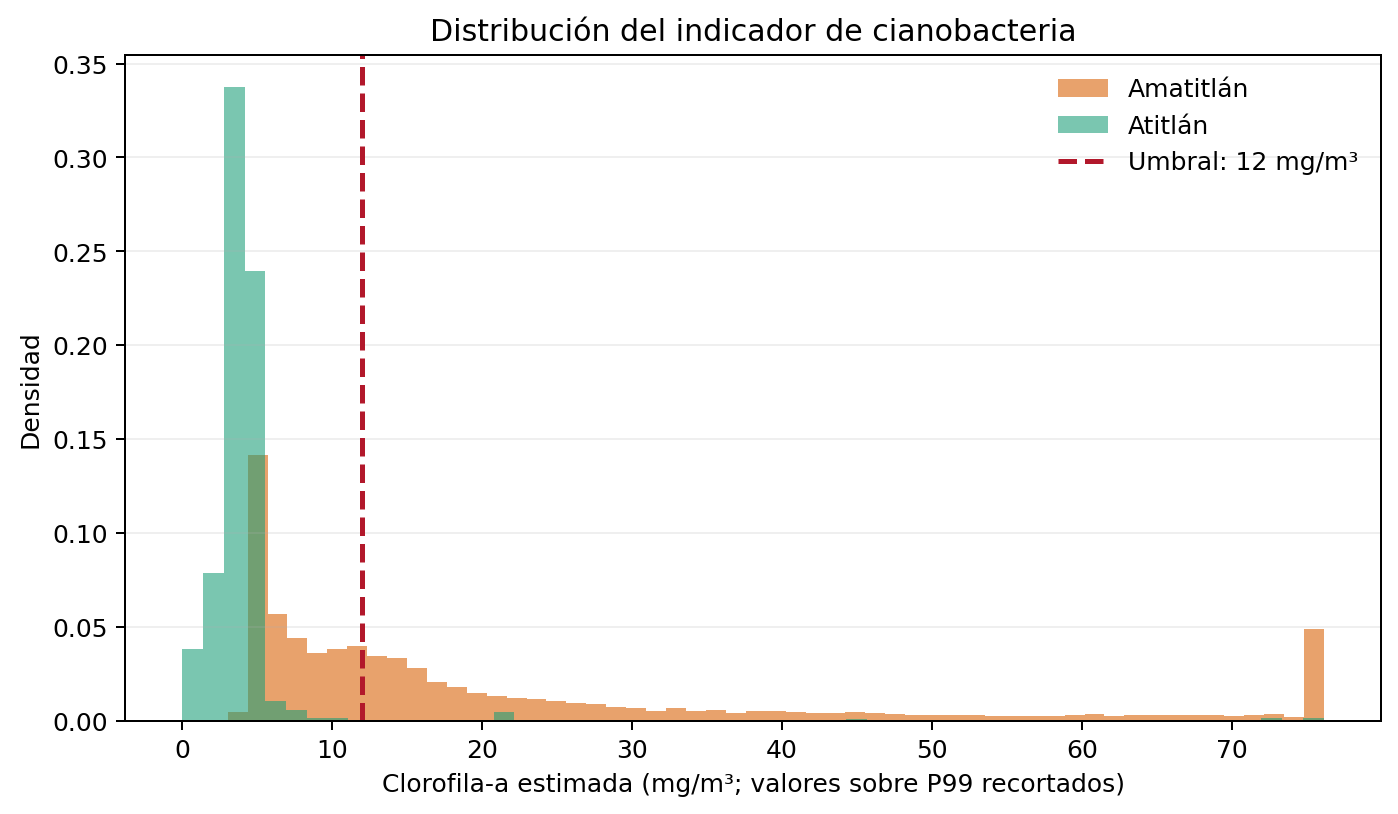

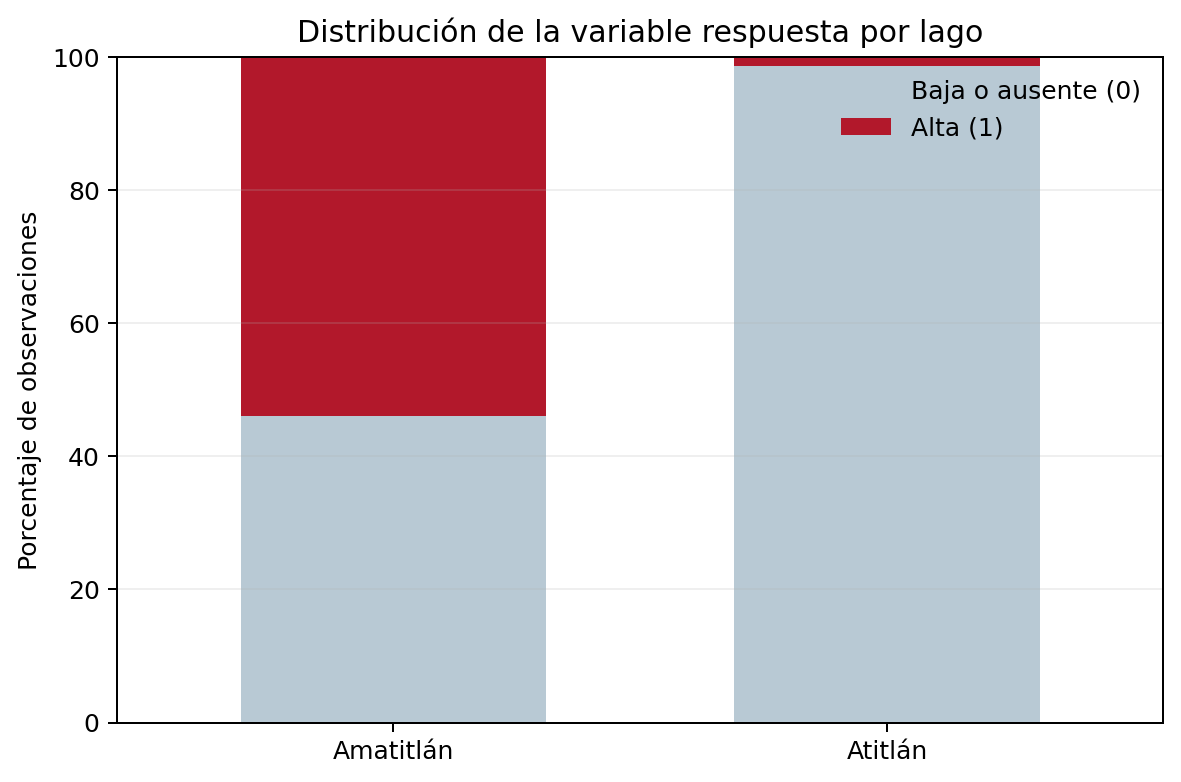

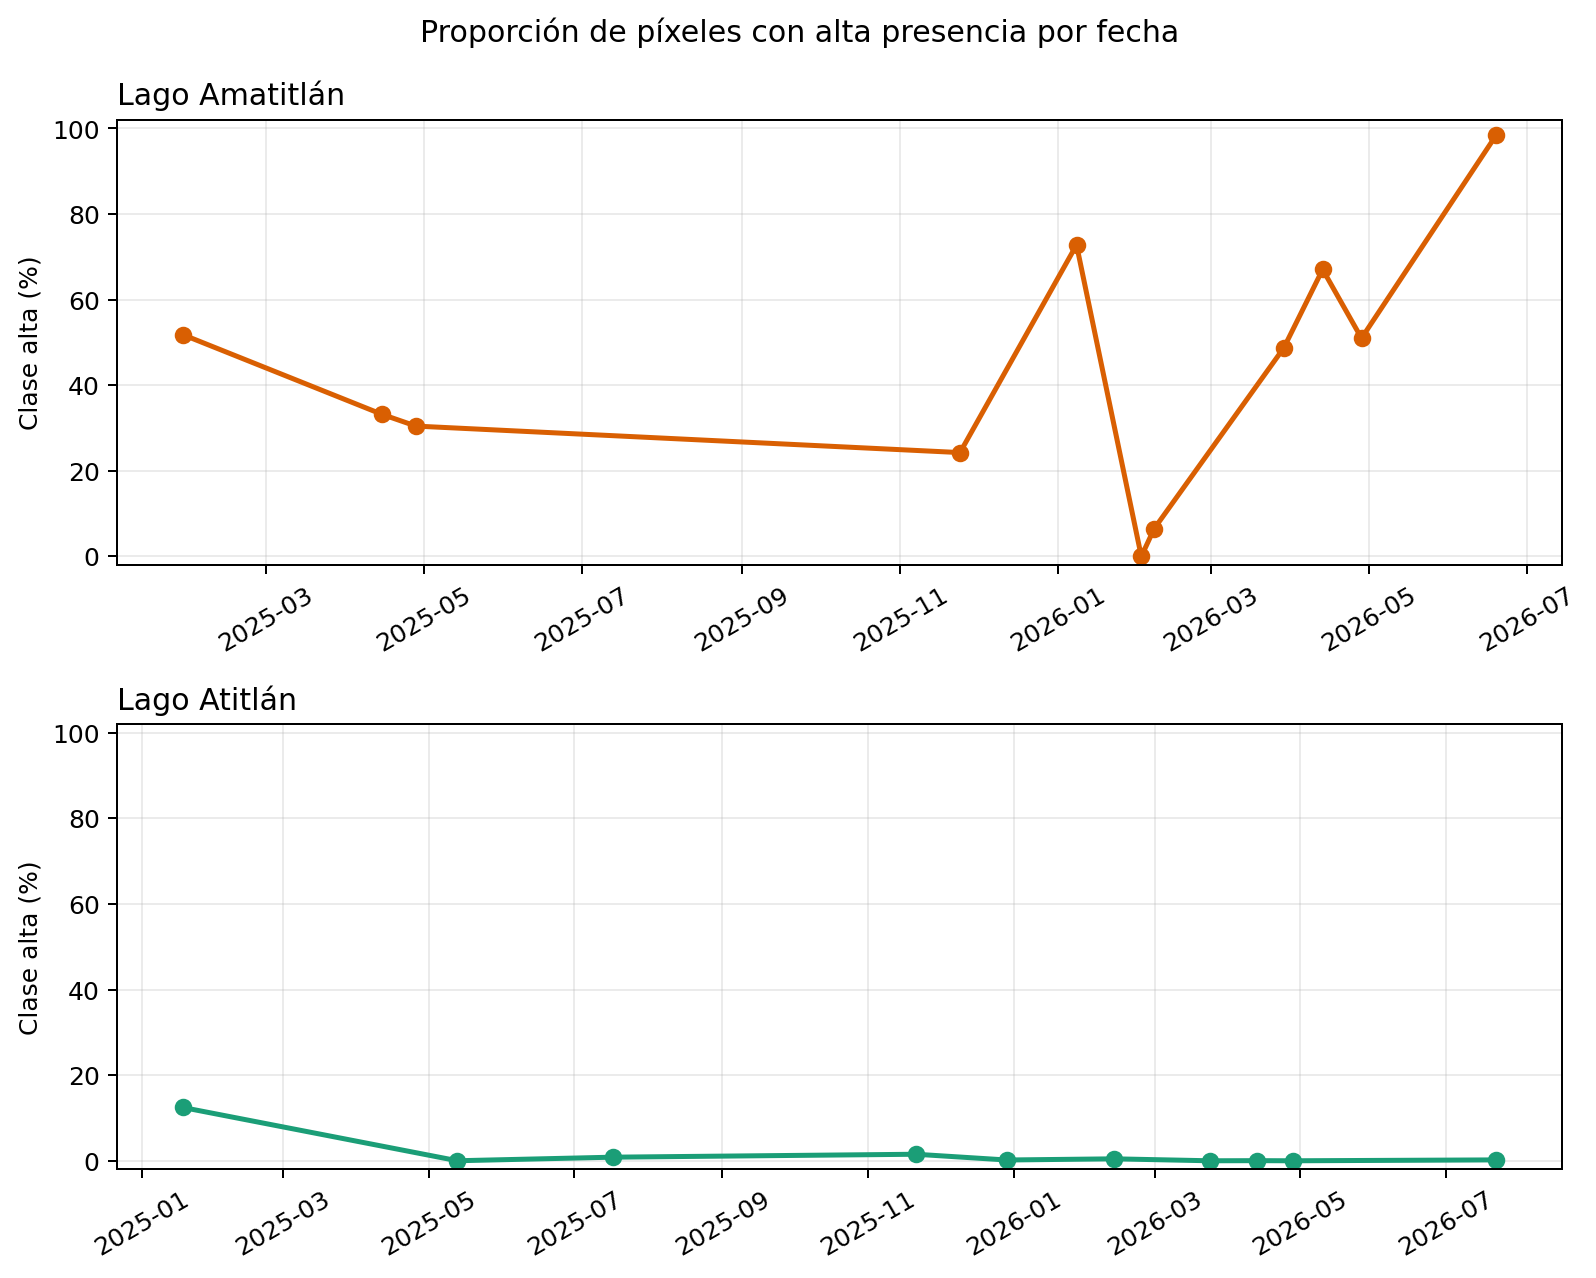

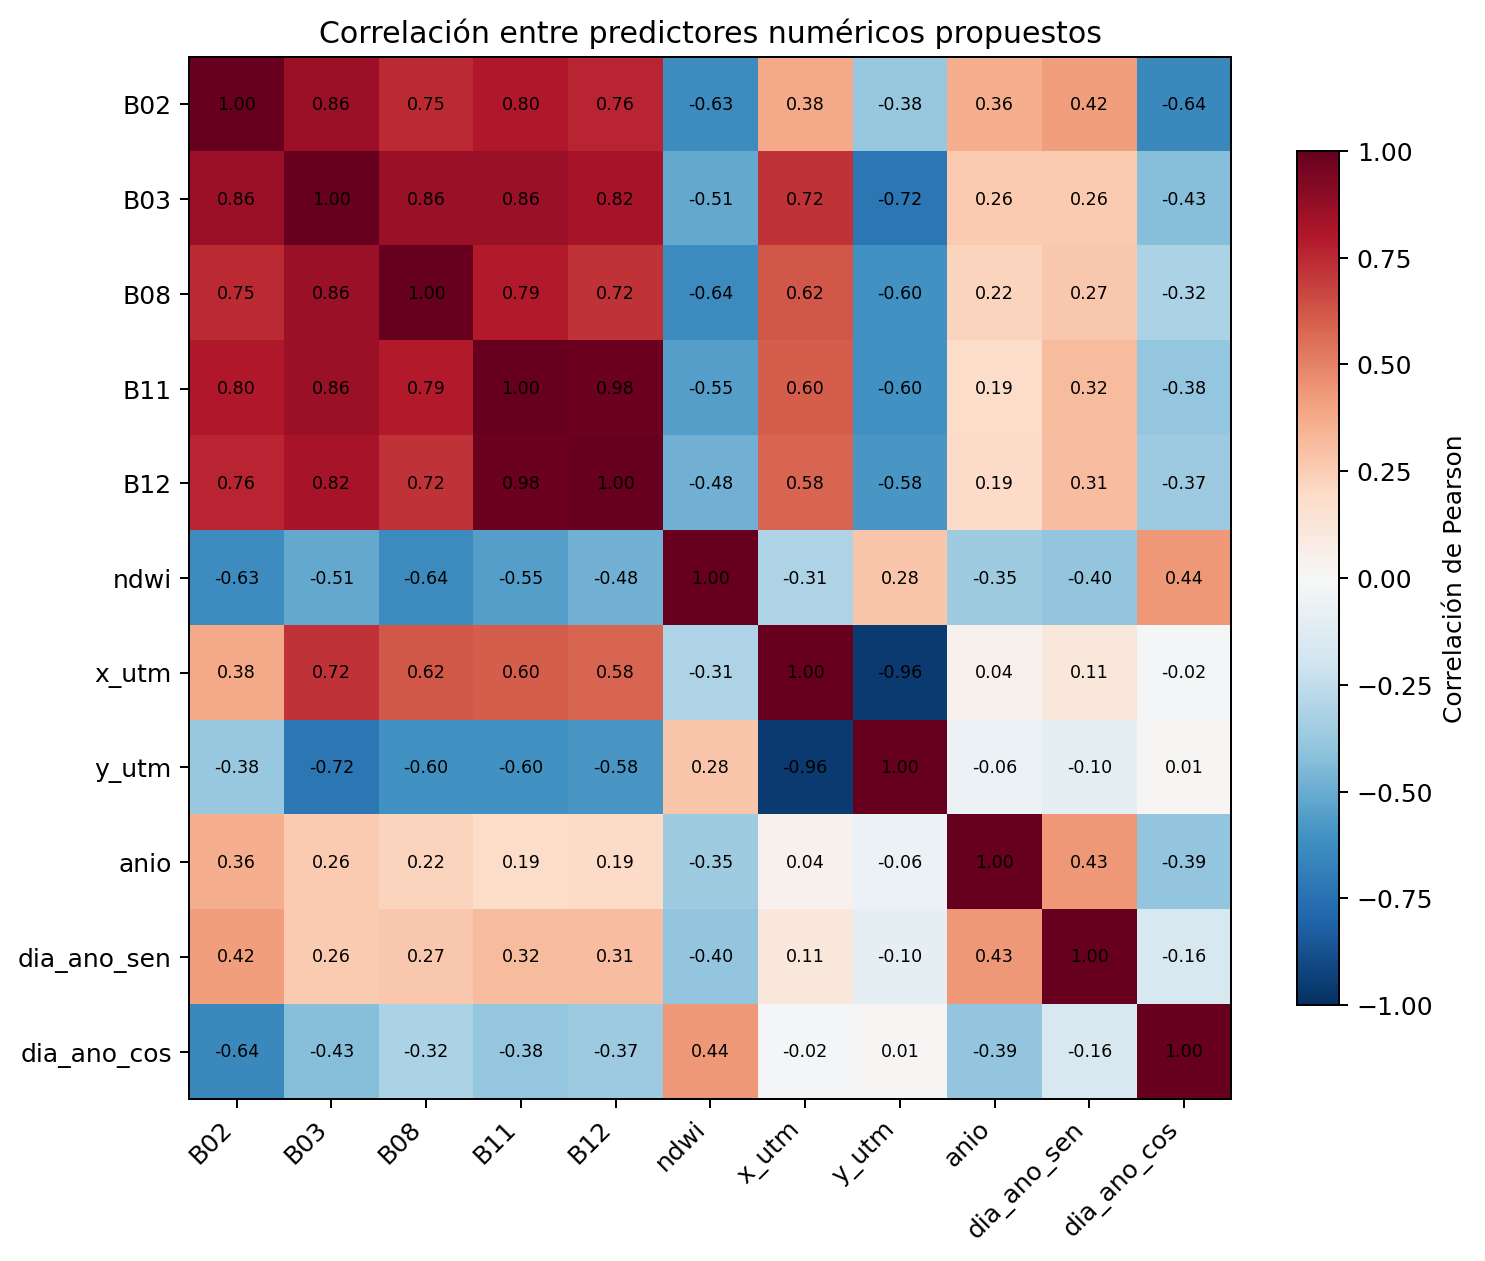

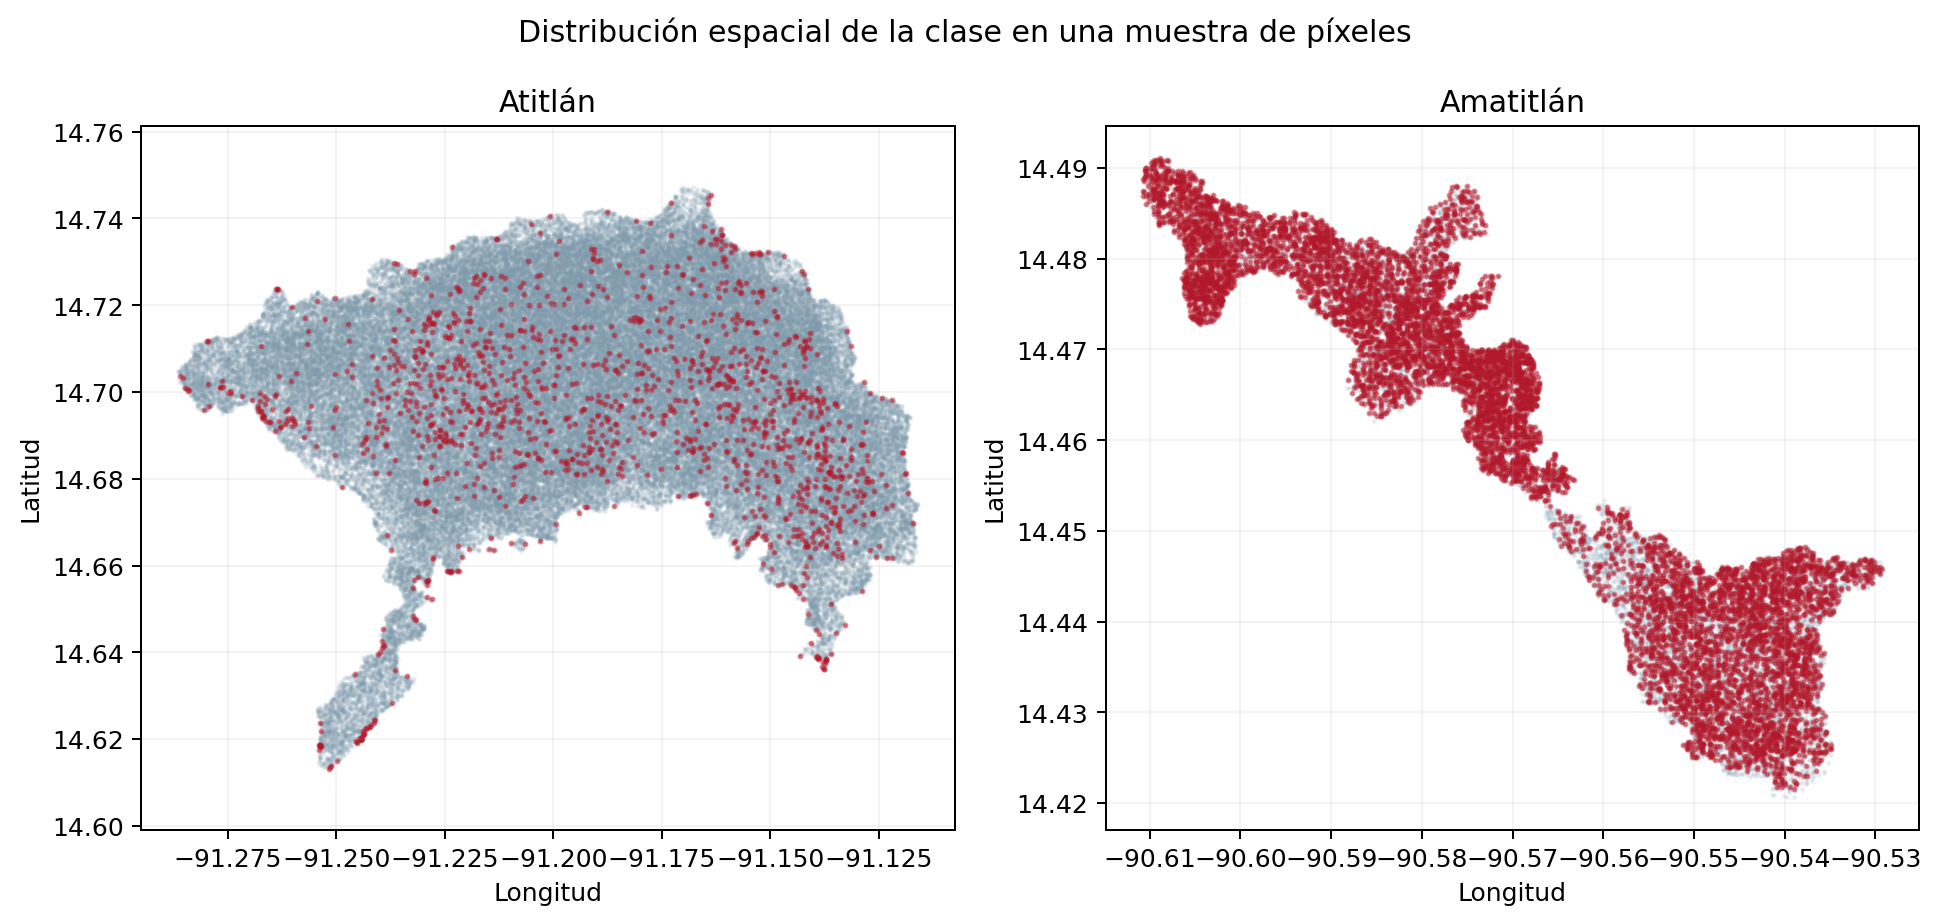

In [7]:
titulos_figuras = {
    "distribucion_cianobacteria.png": "Distribución del indicador de cianobacteria por lago.",
    "clase_por_lago.png": "Distribución porcentual de la variable respuesta por lago.",
    "alta_por_fecha.png": "Proporción de píxeles con clase alta por lago y fecha.",
    "correlacion_predictores.png": "Matriz de correlación de los predictores numéricos.",
    "distribucion_espacial_clase.png": "Distribución espacial de la clase en ambos lagos.",
}

resumenes = construir_resumenes(datos)
archivos_figuras = generar_figuras(datos)
for archivo in archivos_figuras:
    display(Image(filename=str(archivo), width=900, alt=titulos_figuras[archivo.name]))

Las distribuciones muestran dos situaciones distintas. Amatitlán tiene una cola amplia y varias fechas con gran proporción de valores altos; el 19 de junio de 2026 llega a 98.46%. Atitlán se concentra cerca de 4 mg/m³ y solo el 18 de enero de 2025 alcanza 12.46% de píxeles altos. El mapa confirma que la máscara sigue la forma general de ambos lagos y que la clase no se distribuye de manera uniforme.

Las bandas espectrales presentan correlaciones fuertes. B11 y B12, por ejemplo, tienen una correlación cercana a 0.98. Esto puede volver inestables los coeficientes de una regresión logística sin regularización, aunque no representa el mismo problema para modelos basados en árboles. En la etapa de modelado se estandarizarán las variables continuas para la regresión y se revisará si conviene retirar una de las dos bandas SWIR.

## 2. Construcción de la variable respuesta

La etiqueta se construyó a partir de la clorofila-a estimada mediante NDCI:

$$
NDCI = \frac{B05-B04}{B05+B04}
$$

$$
Chl\text{-}a = 826.57(NDCI)^3 - 176.43(NDCI)^2 + 19(NDCI) + 4.071
$$

El polinomio se reprodujo del evalscript de CyanoLakes utilizado en la primera parte.

Se definió `alta_cianobacteria = 1` cuando la estimación es **mayor o igual que 12 mg/m³**, y 0 en caso contrario. Las unidades mg/m³ y µg/L son numéricamente equivalentes. La OMS ubica entre 12 y 24 µg/L de clorofila-a el nivel de alerta 1 para aguas recreativas cuando predominan cianobacterias. Se usa el límite inferior para separar vigilancia de una condición que ya requiere mayor atención.

Este umbral es operativo, no un diagnóstico de toxicidad. La clorofila-a estimada por satélite puede provenir de otros grupos de fitoplancton y el modelo NDCI no fue calibrado con muestras locales de estos dos lagos.

**Referencias:**

- World Health Organization (2021). *Guidelines on recreational water quality, Volume 1: Coastal and fresh waters*. https://www.who.int/publications/i/item/9789240031302
- Mishra, S. y Mishra, D. R. (2012). *Normalized Difference Chlorophyll Index: A novel model for remote estimation of chlorophyll-a concentration in turbid productive waters*. https://doi.org/10.1016/j.rse.2011.10.016
- Kravitz, J. y Matthews, M. (2020). *Cyanobacteria Chlorophyll-a NDCI L1C*. https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/cyanobacteria_chla_ndci_l1c/

In [8]:
distribucion_global = datos["alta_cianobacteria"].value_counts().sort_index().rename("observaciones").to_frame()
distribucion_global["porcentaje"] = 100 * distribucion_global["observaciones"] / len(datos)
distribucion_global.index = ["Baja o ausente (0)", "Alta (1)"]
distribucion_global

,observaciones,porcentaje
Baja o ausente (0),1626436,91.312
Alta (1),154750,8.688


In [9]:
resumenes["por_lago"][[
    "lago", "observaciones", "baja", "alta", "alta_pct",
]].round(2)

,lago,observaciones,baja,alta,alta_pct
0,Amatitlán,247417,113905,133512,53.960
1,Atitlán,1533769,1512531,21238,1.380


In [10]:
tabla_fecha = resumenes["por_fecha"][[
    "lago", "fecha", "observaciones", "baja", "alta", "alta_pct",
]].copy()
tabla_fecha["alta_pct"] = tabla_fecha["alta_pct"].round(2)
tabla_fecha

,lago,fecha,observaciones,baja,alta,alta_pct
0,Amatitlán,2025-01-28,26707,12866,13841,51.830
1,Amatitlán,2025-04-15,9970,6662,3308,33.180
2,Amatitlán,2025-04-28,22053,15336,6717,30.460
3,Amatitlán,2025-11-24,29435,22292,7143,24.270
4,Amatitlán,2026-01-08,30771,8372,22399,72.790
5,Amatitlán,2026-02-02,2441,2441,0,0.000
6,Amatitlán,2026-02-07,7746,7241,505,6.520
7,Amatitlán,2026-03-29,21532,11041,10491,48.720
8,Amatitlán,2026-04-13,33893,11166,22727,67.060
9,Amatitlán,2026-04-28,32697,16022,16675,51.000


### Desbalance de clases

La clase alta representa 8.69% del conjunto completo: hay aproximadamente 10.5 observaciones bajas por cada observación alta. El desbalance es todavía más fuerte dentro de Atitlán, donde solo 1.38% pertenece a la clase 1, mientras que en Amatitlán la clase alta es mayoritaria con 53.96%.

Por esta razón, accuracy por sí sola puede producir una conclusión engañosa. Un modelo que casi siempre prediga 0 tendría una accuracy global alta y aun así omitiría las zonas de interés ambiental. En los ejercicios posteriores se mantendrá una partición estratificada, se probará ponderación de clases dentro del conjunto de entrenamiento y se priorizará recall/F1 de la clase alta junto con ROC-AUC. El conjunto de prueba no se balanceará artificialmente.

### Variables que producirían fuga de información

In [11]:
fuga = pd.DataFrame([
    ("B04", "Se usa directamente en NDCI."),
    ("B05", "Se usa directamente en NDCI."),
    ("ndci", "Es la entrada directa del polinomio que genera la etiqueta."),
    ("cianobacteria_mg_m3", "La clase se obtiene aplicando el umbral a esta misma variable."),
    ("ndvi", "Comparte B04 con NDCI; se excluye por dependencia indirecta."),
], columns=["variable excluida", "motivo"])
fuga

,variable excluida,motivo
0,B04,Se usa directamente en NDCI.
1,B05,Se usa directamente en NDCI.
2,ndci,Es la entrada directa del polinomio que genera...
3,cianobacteria_mg_m3,La clase se obtiene aplicando el umbral a esta...
4,ndvi,Comparte B04 con NDCI; se excluye por dependen...


B04 y B05 se conservaron en el archivo para trazabilidad y para poder reproducir la etiqueta, pero no entrarán a ningún modelo. Tampoco se usará una transformación, razón o combinación que vuelva a introducirlas.

## 3. Selección y construcción de variables predictoras

In [12]:
predictores = pd.DataFrame([
    ("B02", "Banda espectral", "Reflectancia azul; responde a dispersión y cambios de color del agua."),
    ("B03", "Banda espectral", "Reflectancia verde; puede cambiar con pigmentos y claridad del agua."),
    ("B08", "Banda espectral", "Infrarrojo cercano; ayuda a diferenciar agua, material flotante y bordes."),
    ("B11", "Banda espectral", "SWIR 1; aporta contraste ante humedad, turbidez y contaminación residual."),
    ("B12", "Banda espectral", "SWIR 2; complementa B11, aunque ambas están muy correlacionadas."),
    ("ndwi", "Índice", "Resume el contraste verde-NIR sin utilizar B04 ni B05."),
    ("x_utm, y_utm", "Espacial", "Conservan gradientes y sectores del lago en una unidad métrica."),
    ("lago", "Geográfica categórica", "Representa diferencias de tamaño, cuenca y comportamiento espectral."),
    ("anio", "Temporal", "Permite separar las dos temporadas anuales observadas."),
    ("dia_ano_sen, dia_ano_cos", "Temporal cíclica", "Representan estacionalidad sin crear un salto entre diciembre y enero."),
], columns=["variable", "tipo", "justificación"])
predictores

,variable,tipo,justificación
0,B02,Banda espectral,Reflectancia azul; responde a dispersión y cam...
1,B03,Banda espectral,Reflectancia verde; puede cambiar con pigmento...
2,B08,Banda espectral,"Infrarrojo cercano; ayuda a diferenciar agua, ..."
3,B11,Banda espectral,"SWIR 1; aporta contraste ante humedad, turbide..."
4,B12,Banda espectral,"SWIR 2; complementa B11, aunque ambas están mu..."
5,ndwi,Índice,Resume el contraste verde-NIR sin utilizar B04...
6,"x_utm, y_utm",Espacial,Conservan gradientes y sectores del lago en un...
7,lago,Geográfica categórica,"Representa diferencias de tamaño, cuenca y com..."
8,anio,Temporal,Permite separar las dos temporadas anuales obs...
9,"dia_ano_sen, dia_ano_cos",Temporal cíclica,Representan estacionalidad sin crear un salto ...


El conjunto inicial de predictores será:

```python
[
    "B02", "B03", "B08", "B11", "B12", "ndwi",
    "x_utm", "y_utm", "anio", "dia_ano_sen", "dia_ano_cos", "lago"
]
```

`lago` se codificará con one-hot encoding. Las variables continuas se estandarizarán dentro del pipeline de regresión logística; los modelos de árboles recibirán los valores originales. Longitud y latitud no se incluyen porque duplican la ubicación de `x_utm` y `y_utm`; `mes` no se incluye porque la estacionalidad ya está representada con seno y coseno; satélite, fila y columna se mantienen solo como metadatos.

La inclusión de coordenadas puede inflar una validación aleatoria por autocorrelación espacial. Por eso su utilidad se evaluará nuevamente con los bloques espaciales solicitados en la siguiente etapa.

## Conclusiones del avance

- Se construyó un conjunto de 1,781,186 píxeles válidos con coordenadas, fecha, lago, bandas e índices. Después de la limpieza no quedaron valores faltantes.
- Se utilizó 12 mg/m³ como punto de corte por corresponder al inicio del nivel de alerta 1 de la OMS cuando predominan cianobacterias.
- La clase alta representa 8.69% globalmente y está distribuida de manera muy distinta entre los lagos, por lo que accuracy no será suficiente para evaluar los modelos.
- Se excluyeron B04, B05, NDCI, clorofila-a estimada y NDVI para evitar fuga de información.
- El conjunto predictor conserva información espectral, espacial y temporal sin reutilizar las variables que construyen la respuesta.